# Rozgrzewka 1: DQN (sieć) na CartPole — **najprostsza możliwa implementacja**

Chcesz przejść ścieżką:
**CartPole intuicja → sieć + TD (DQN) → REINFORCE → A2C → PPO**.

W tej rozgrzewce robimy brakujący most: **value-based RL z siecią** na *prostym kodzie* (bez frameworków typu Stable-Baselines).

## Co ma zaskoczyć po tym notebooku

1. **Q-learning** to uczenie funkcji \(Q(s,a)\) przez **TD target (Bellman)**.
2. W środowiskach ciągłych (CartPole) nie mamy tablicy → $Q(s,a)$ aproksymuje **sieć MLP**.
3. DQN to tak naprawdę:
   - **epsilon-greedy** (eksploracja),
   - **replay buffer** (losowe próbki),
   - **target network** (stabilny target),
   - **loss**: $\|y - Q_\theta(s,a)\|^2$ (Huber/MSE),
   - **gradient descent**.

> Uwaga: w CartPole macie nawet dobrą heurystykę (z rozgrzewki 0), ale tutaj uczymy się tego **jak się uczy sieć**, a nie jak ręcznie wymyślić regułę.

---

## Wymagania

Jeśli w Twoim środowisku brakuje paczek, odkomentuj i uruchom:

```python
# !pip -q install gymnasium[classic-control]
# # albo (stare środowiska):
# # !pip -q install gym[classic_control]
# !pip -q install torch numpy matplotlib
```

## 0) Setup: importy, device, helpery

Poniżej jest kod, który:
- importuje biblioteki,
- robi fallback: `gymnasium` → `gym`,
- ustawia seedy,
- definiuje `moving_average()` do wykresów.

In [75]:
import random
from collections import deque

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# --- gymnasium -> gym fallback ---
try:
    import gymnasium as gym
    GYM_API = "gymnasium"
except Exception:
    try:
        import gym
        GYM_API = "gym"
    except Exception as e:
        raise ImportError(
            "Nie widzę ani `gymnasium`, ani `gym`.\n"
            "Zainstaluj np.:  pip install gymnasium[classic-control]\n"
        ) from e

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device, "| gym api:", GYM_API)

def seed_everything(seed: int = 0):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def moving_average(x, window=50):
    x = np.asarray(x, dtype=float)
    if len(x) < window:
        return x
    return np.convolve(x, np.ones(window)/window, mode="valid")

device: cpu | gym api: gymnasium


## 1) Powtórka: Q-learning w jednym wzorze (dlaczego w ogóle DQN?)

W tablicowym Q-learning uczymy:
$
Q(s,a)\approx \mathbb{E}[G_t \mid s_t=s, a_t=a]
$

Update (intuicyjnie):
$
Q(s,a)\leftarrow Q(s,a) + \alpha\Big(r + \gamma \max_{a'}Q(s',a') - Q(s,a)\Big)
$

To co jest w nawiasie, to **TD error**:
$
\delta = r + \gamma \max_{a'}Q(s',a') - Q(s,a)
$

W DQN robimy prawie to samo, tylko zamiast tablicy mamy sieć:
$
Q_\theta(s,a)
$

i uczymy parametry $\theta$ przez minimalizację lossu:
$
\mathcal{L}(\theta) = \text{Huber}\big(Q_\theta(s,a),\ y\big),
\quad y=r+\gamma(1-d)\max_{a'}Q_{\theta^-}(s',a')
$

gdzie:
- $d$ to `done` (koniec epizodu),
- $\theta^-$ to parametry **target network** (zamrożone na chwilę).

---

### Dlaczego replay buffer i target network?

- Replay buffer: kolejne stany są mocno skorelowane → SGD wariuje. Losowanie batcha „odkleja” próbki.
- Target network: gdy target zależy od tej samej sieci, która się uczy, to target „ucieka” → niestabilność.

### Huber loss — co to jest i dlaczego używamy go w DQN?

W DQN minimalizujemy błąd między:

$Q_\theta(s,a)$

a targetem:

$y = r + \gamma (1 - d)\max_{a'} Q_{\theta^-}(s',a')$

Naturalnym pomysłem byłby klasyczny MSE:

$\frac{1}{2}(Q_\theta - y)^2$

Problem: jeśli błąd jest bardzo duży (np. na początku treningu),
gradient rośnie proporcjonalnie do błędu → może powodować niestabilność.

Dlatego używamy **Huber loss** (w PyTorch: `smooth_l1_loss`).

Definicja (dla błędu $e = Q_\theta - y$, próg $\delta$):

$
\text{Huber}_\delta(e) =
\begin{cases}
\frac{1}{2} e^2 & \text{gdy } |e| \le \delta \\
\delta\left(|e| - \frac{1}{2}\delta\right) & \text{gdy } |e| > \delta
\end{cases}
$

Interpretacja:

- dla małych błędów → zachowuje się jak MSE (gładkie uczenie),
- dla dużych błędów → przechodzi w MAE (ogranicza wpływ outlierów).

W praktyce:
- stabilniejsze uczenie niż czyste MSE,
- mniejsze ryzyko eksplozji gradientu.


### Target Network — dlaczego potrzebujemy drugiej sieci?

W klasycznym Q-learning target to:

$r + \gamma \max_{a'} Q(s',a')$

W DQN:

$
y = r + \gamma (1-d)\max_{a'} Q_{\theta^-}(s',a')
$

Dlaczego używamy $\theta^-$ zamiast tej samej sieci $\theta$?

Problem bez target network:

- target zależy od tej samej sieci, którą właśnie aktualizujemy,
- każda zmiana parametrów zmienia także target,
- target „ucieka” podczas uczenia,
- prowadzi to do niestabilności i oscylacji.

Rozwiązanie: **Target Network**.

- kopiujemy parametry: $\theta^- \leftarrow \theta$,
- zamrażamy je na pewien czas,
- używamy ich tylko do liczenia targetów,
- aktualizujemy je co $N$ kroków.

Efekt:
- target zmienia się wolniej,
- optymalizacja staje się stabilniejsza,
- gradient „goni” względnie stały cel.


## 2) CartPole: szybki check środowiska i baseline

To samo środowisko co w rozgrzewce 0.
W CartPole:
- obserwacja ma 4 liczby,
- akcje są 2 (0=lewo, 1=prawo),
- nagroda to 1 za każdy krok utrzymania kija (do max 500).

In [76]:
def make_env(env_name: str = "CartPole-v1", seed: int = 0, render: bool = False):
    """Tworzy środowisko. Render zwykle wyłączamy podczas treningu (spowalnia)."""
    if GYM_API == "gymnasium":
        env = gym.make(env_name, render_mode=("human" if render else None))
        env.reset(seed=seed)
        try:
            env.action_space.seed(seed)
        except Exception:
            pass
        return env
    else:
        env = gym.make(env_name)
        try:
            env.seed(seed)
            env.action_space.seed(seed)
        except Exception:
            pass
        return env

def reset_env(env, seed=None):
    if GYM_API == "gymnasium":
        obs, info = env.reset(seed=seed)
        return obs
    else:
        if seed is not None:
            try:
                env.seed(seed)
            except Exception:
                pass
        return env.reset()

def step_env(env, action):
    """Uwaga dydaktyczna:
    - gymnasium zwraca (terminated, truncated).
    - Dla *prostoty* traktujemy `done = terminated OR truncated`.
      (Bardziej poprawnie: do targetu TD zwykle używa się tylko `terminated`,
       a `truncated` traktuje jak 'timeout' i dalej bootstrapuje).
    """
    if GYM_API == "gymnasium":
        obs2, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        return obs2, float(reward), bool(done)
    else:
        obs2, reward, done, info = env.step(action)
        return obs2, float(reward), bool(done)

def evaluate_policy(env_name, policy_fn, episodes=20, seed=0):
    env = make_env(env_name, seed=seed, render=False)
    returns = []
    for ep in range(episodes):
        obs = reset_env(env, seed=seed + ep)
        total = 0.0
        done = False
        while not done:
            a = int(policy_fn(obs))
            obs, r, done = step_env(env, a)
            total += r
        returns.append(total)
    env.close()
    return float(np.mean(returns)), float(np.std(returns))

# baseline: losowa polityka (żeby wiedzieć, od czego startujemy)
baseline_random_mean, baseline_random_std = evaluate_policy(
    "CartPole-v1",
    policy_fn=lambda obs: random.randint(0, 1),
    episodes=30,
    seed=0,
)
print(f"[baseline] Random policy: mean±std = {baseline_random_mean:.1f} ± {baseline_random_std:.1f}")

[baseline] Random policy: mean±std = 23.4 ± 16.1


## 3) Replay Buffer (minimalny)

Przechowujemy przejścia:
$
(s,a,r,s',done)
$

i losujemy z niego batch do uczenia.

### Replay Buffer — po co przechowujemy przejścia?

Podczas treningu agent generuje sekwencję przejść:

$(s_t, a_t, r_t, s_{t+1}, done)$

Kolejne stany są silnie skorelowane w czasie.

Jeśli uczylibyśmy sieć na bieżących krokach:
- próbki byłyby prawie identyczne,
- gradient byłby niestabilny,
- rozkład danych byłby niestacjonarny.

Rozwiązanie: **Replay Buffer**.

Replay Buffer:
- przechowuje wiele przejść z przeszłości,
- pozwala losować batch $\{(s_i, a_i, r_i, s_i', d_i)\}_{i=1}^B$,
- przybliża i.i.d. sampling (bardziej stabilne SGD).

W DQN loss minimalizujemy na batchu:

$
\mathcal{L}(\theta) =
\frac{1}{B} \sum_{i=1}^{B}
\text{Huber}\left(
Q_\theta(s_i,a_i),
r_i + \gamma (1-d_i) \max_{a'} Q_{\theta^-}(s_i',a')
\right)
$

Efekt:
- stabilniejsze uczenie,
- efektywniejsze wykorzystanie doświadczenia,
- mniejsza korelacja próbek.


In [77]:
class ReplayBuffer:
    def __init__(self, capacity: int):
        self.buffer = deque(maxlen=capacity)

    def add(self, s, a, r, s2, done):
        self.buffer.append((np.array(s, dtype=np.float32),
                            int(a),
                            float(r),
                            np.array(s2, dtype=np.float32),
                            bool(done)))

    # alias dla kompatybilności z innymi wersjami
    push = add
    def sample(self, batch_size: int):
        batch = random.sample(self.buffer, batch_size)
        s, a, r, s2, done = map(np.array, zip(*batch))
        # s: (B, obs_dim), a: (B,), r: (B,), s2: (B, obs_dim), done: (B,)
        return s, a, r.astype(np.float32), s2, done.astype(np.float32)

    def __len__(self):
        return len(self.buffer)

## 4) Sieć Q: mały MLP

Najprościej:
- wejście: 4 liczby (stan),
- wyjście: 2 liczby (Q dla akcji 0 i 1).

In [78]:
class QNet(nn.Module):
    def __init__(self, obs_dim: int, act_dim: int, hidden: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, act_dim),
        )

    def forward(self, x):
        return self.net(x)

# szybki sanity-check kształtów
env = make_env(seed=0, render=False)
obs_dim = env.observation_space.shape[0]
act_dim = env.action_space.n
env.close()

q = QNet(obs_dim, act_dim).to(device)
test = torch.zeros((3, obs_dim), dtype=torch.float32, device=device)
print("Q(s,·) shape =", q(test).shape)  # (batch, act_dim)

Q(s,·) shape = torch.Size([3, 2])


## 5) Wybór akcji: epsilon-greedy

Z prawdopodobieństwem \(\epsilon\) robimy losową akcję (eksploracja),
a w przeciwnym razie bierzemy \(\arg\max_a Q(s,a)\) (eksploatacja).

Zrobimy prosty **liniowy** harmonogram \(\epsilon\) po krokach.

In [79]:
def epsilon_by_step(step: int, eps_start=1.0, eps_end=0.05, decay_steps=20_000):
    # liniowo: 1.0 -> 0.05
    frac = max(0.0, 1.0 - step / float(decay_steps))
    return eps_end + (eps_start - eps_end) * frac

@torch.no_grad()
def greedy_action(q_net: nn.Module, obs: np.ndarray) -> int:
    obs_t = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)  # (1, obs_dim)
    q_values = q_net(obs_t)  # (1, act_dim)
    return int(torch.argmax(q_values, dim=1).item())

def select_action(q_net: nn.Module, obs: np.ndarray, epsilon: float, act_dim: int) -> int:
    if random.random() < epsilon:
        return random.randrange(act_dim)
    return greedy_action(q_net, obs)

## 6) Jedna aktualizacja DQN (najważniejszy fragment)

Bierzemy batch z bufora i liczymy:

- **predykcję**: $Q_\theta(s,a)$
- **target**: $y = r + \gamma (1-d)\max_{a'} Q_{\theta^-}(s',a')$

Potem robimy krok optymalizatora po Huber loss.

To jest dokładny analog tablicowego update'u, tylko zamiast:
$
Q \leftarrow Q + \alpha \delta
$
robimy SGD na parametrach sieci.

In [80]:
def dqn_update(q_net, q_tgt, optimizer, batch, gamma: float = 0.99):
    s, a, r, s2, done = batch

    s_t  = torch.tensor(s,  dtype=torch.float32, device=device)  # (B, obs_dim)
    a_t  = torch.tensor(a,  dtype=torch.int64,   device=device).unsqueeze(1)  # (B, 1)
    r_t  = torch.tensor(r,  dtype=torch.float32, device=device)  # (B,)
    s2_t = torch.tensor(s2, dtype=torch.float32, device=device)  # (B, obs_dim)
    d_t  = torch.tensor(done, dtype=torch.float32, device=device)  # (B,)

    # Q_theta(s,a) dla akcji z batcha
    q_sa = q_net(s_t).gather(1, a_t).squeeze(1)  # (B,)

    with torch.no_grad():
        # max_a' Q_target(s',a')
        q_next = q_tgt(s2_t).max(dim=1).values  # (B,)
        y = r_t + gamma * (1.0 - d_t) * q_next

    loss = F.smooth_l1_loss(q_sa, y)

    optimizer.zero_grad()
    loss.backward()
    nn.utils.clip_grad_norm_(q_net.parameters(), 10.0)
    optimizer.step()

    return float(loss.item())

## 7) Trening DQN (CartPole)

Poniżej masz **jedną** funkcję treningową.  
Warto czytać ją powoli — to cały algorytm.

**Parametry, które najczęściej decydują czy „zaskoczy”:**
- `lr`
- `start_learning` (ile kroków zbieramy zanim zaczniemy uczyć)
- `target_update` (co ile kroków kopiujemy wagi do target)
- `eps_decay_steps` (jak szybko schodzimy z eksploracji)

W CartPole typowo wystarczy ~300–600 epizodów, zależnie od losowości.

In [81]:
def train_dqn(
    seed=0,
    episodes=500,
    gamma=0.99,
    lr=3e-4,                  # trochę mniejszy LR zwykle stabilniejszy
    hidden=128,
    buffer_capacity=50_000,
    batch_size=64,
    start_learning=1_000,
    train_freq=1,
    target_update=500,         # częstszy hard-update target często pomaga w CartPole
    eps_start=1.0,
    eps_end=0.05,
    eps_decay_steps=10_000,    # szybciej schodzimy z eps (żeby w 400 ep zobaczyć efekt)
    max_steps=500,
    eval_every=50,             # co ile epizodów robimy krótką ewaluację greedy
    eval_episodes=10,
):
    seed_everything(seed)

    env = make_env("CartPole-v1", seed=seed, render=False)
    obs_dim = env.observation_space.shape[0]
    act_dim = env.action_space.n

    q_net = QNet(obs_dim, act_dim, hidden=hidden).to(device)
    q_tgt = QNet(obs_dim, act_dim, hidden=hidden).to(device)
    q_tgt.load_state_dict(q_net.state_dict())
    q_tgt.eval()

    optimizer = optim.Adam(q_net.parameters(), lr=lr)
    buffer = ReplayBuffer(buffer_capacity)

    returns = []
    mean_losses = []
    eps_hist = []
    eval_points = []  # list[(episode, greedy_mean_return)]

    global_step = 0

    for ep in range(episodes):
        obs = reset_env(env, seed=seed + ep)
        ep_return = 0.0
        ep_losses = []

        for t in range(max_steps):
            eps = epsilon_by_step(global_step, eps_start, eps_end, eps_decay_steps)
            a = select_action(q_net, obs, eps, act_dim)

            obs2, r, done = step_env(env, a)
            buffer.push(obs, a, r, obs2, done)

            obs = obs2
            ep_return += r

            # uczymy się dopiero jak mamy coś w buforze
            if len(buffer) >= start_learning and (global_step % train_freq == 0):
                batch = buffer.sample(batch_size)
                loss = dqn_update(q_net, q_tgt, optimizer, batch, gamma=gamma)
                ep_losses.append(loss)

            # aktualizacja target network (hard update)
            if global_step % target_update == 0:
                q_tgt.load_state_dict(q_net.state_dict())

            global_step += 1
            if done:
                break

        returns.append(ep_return)
        mean_losses.append(float(np.mean(ep_losses)) if ep_losses else np.nan)
        eps_hist.append(eps)

        # Krótka ewaluacja greedy (bez eps) — pokazuje 'prawdziwą' jakość polityki
        if eval_every and ((ep + 1) % eval_every == 0):
            mean_eval, std_eval = evaluate_policy(
                "CartPole-v1",
                policy_fn=lambda ob: greedy_action(q_net, ob),
                episodes=eval_episodes,
                seed=seed + 10_000 + ep,
            )
            eval_points.append((ep + 1, mean_eval))
            print(f"   [eval] ep {ep+1:4d} | greedy mean±std = {mean_eval:6.1f} ± {std_eval:4.1f}")

        if (ep + 1) % 20 == 0:
            ma50 = np.mean(returns[-50:]) if len(returns) >= 50 else np.mean(returns)
            print(f"ep {ep+1:4d} | return={ep_return:6.1f} | MA50={ma50:6.1f} | eps={eps:5.3f} | buffer={len(buffer):6d} | steps={global_step:6d}")

    env.close()

    stats = {
        "returns": returns,
        "loss": mean_losses,
        "epsilon": eps_hist,
        "eval_points": eval_points,
        "steps": global_step,
    }
    return q_net, stats

# --- uruchom trening ---
q_net, stats = train_dqn(episodes=400, seed=0)


ep   20 | return=  65.0 | MA50=  26.9 | eps=0.949 | buffer=   539 | steps=   539
ep   40 | return=  20.0 | MA50=  27.1 | eps=0.897 | buffer=  1086 | steps=  1086
   [eval] ep   50 | greedy mean±std =   10.1 ±  1.0
ep   60 | return=  22.0 | MA50=  25.1 | eps=0.857 | buffer=  1509 | steps=  1509
ep   80 | return=  33.0 | MA50=  23.9 | eps=0.814 | buffer=  1962 | steps=  1962
   [eval] ep  100 | greedy mean±std =  465.9 ± 31.8
ep  100 | return=  15.0 | MA50=  28.5 | eps=0.742 | buffer=  2719 | steps=  2719
ep  120 | return=  27.0 | MA50=  35.9 | eps=0.666 | buffer=  3522 | steps=  3522
ep  140 | return=  17.0 | MA50=  40.0 | eps=0.598 | buffer=  4232 | steps=  4232
   [eval] ep  150 | greedy mean±std =  247.2 ± 33.6
ep  160 | return=  37.0 | MA50=  56.1 | eps=0.437 | buffer=  5928 | steps=  5928
ep  180 | return= 320.0 | MA50=  97.6 | eps=0.164 | buffer=  8799 | steps=  8799
   [eval] ep  200 | greedy mean±std =  126.3 ±  4.5
ep  200 | return= 123.0 | MA50= 147.3 | eps=0.050 | buffer= 122

## 8) Wykresy: zwrot, epsilon, loss

Patrzymy głównie na:
- `return` i `MA50` (czy rośnie do ~500),
- `epsilon` (czy schodzi),
- `loss` (nie musi monotonnie maleć, ale nie powinien eksplodować).

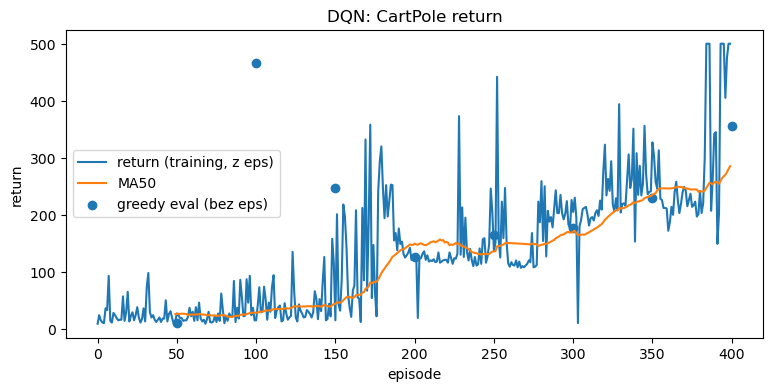

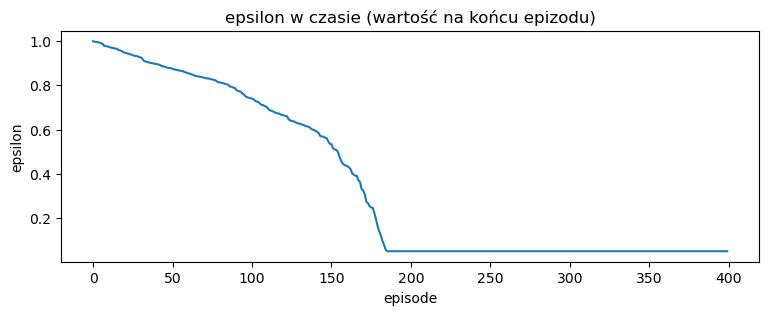

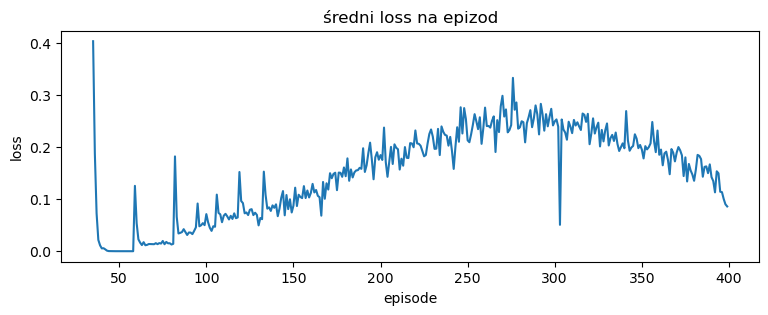

Łącznie kroków (transitions): 53398


In [82]:
returns = stats["returns"]
losses = stats["loss"]
eps = stats["epsilon"]
eval_points = stats.get("eval_points", [])

plt.figure(figsize=(9,4))
plt.plot(returns, label="return (training, z eps)")
ma = moving_average(returns, 50)
plt.plot(range(49, 49+len(ma)), ma, label="MA50")
if len(eval_points) > 0:
    xs, ys = zip(*eval_points)
    plt.scatter(xs, ys, label="greedy eval (bez eps)")
plt.title("DQN: CartPole return")
plt.xlabel("episode")
plt.ylabel("return")
plt.legend()
plt.show()

plt.figure(figsize=(9,3))
plt.plot(eps)
plt.title("epsilon w czasie (wartość na końcu epizodu)")
plt.xlabel("episode")
plt.ylabel("epsilon")
plt.show()

plt.figure(figsize=(9,3))
plt.plot(losses)
plt.title("średni loss na epizod")
plt.xlabel("episode")
plt.ylabel("loss")
plt.show()

print("Łącznie kroków (transitions):", stats.get("steps", None))


## 9) Ewaluacja: greedy policy (bez eksploracji)

To ważne: podczas treningu agent robi dużo losowych akcji (epsilon).  
Na koniec sprawdzamy, jak działa **czysta** polityka greedy.

> Jeśli jesteś na maszynie z GUI: możesz też odpalić render (na dole).

In [83]:
# Upewnij się, że masz wytrenowany `q_net` (uruchom trening w sekcji 7).

try:
    print(f"Random baseline: mean±std = {baseline_random_mean:.1f} ± {baseline_random_std:.1f}")
except Exception:
    pass

def greedy_policy_fn(obs):
    return greedy_action(q_net, obs)

mean_r, std_r = evaluate_policy("CartPole-v1", greedy_policy_fn, episodes=30, seed=123)
print(f"Greedy (trained) policy: mean±std = {mean_r:.1f} ± {std_r:.1f}")

# (opcjonalnie, lokalnie z GUI) zagraj 2 epizody z renderem:
# env = make_env("CartPole-v1", seed=0, render=True)
# for ep in range(2):
#     obs = reset_env(env, seed=0+ep)
#     done = False
#     while not done:
#         a = greedy_action(q_net, obs)
#         obs, r, done = step_env(env, a)
# env.close()


Random baseline: mean±std = 23.4 ± 16.1
Greedy (trained) policy: mean±std = 304.8 ± 76.0


# Ćwiczenia

## Wspólny runner:

In [ ]:
def train_dqn_experiment(
    update_fn,
    sample_fn,
    epsilon_fn,
    *,
    seed=0,
    episodes=200,
    gamma=0.99,
    lr=3e-4,
    hidden=128,
    buffer_capacity=50_000,
    batch_size=64,
    start_learning=1_000,
    train_freq=1,
    target_update=500,
    max_steps=500,
    eval_every=50,
    eval_episodes=10,
    use_target=True,
    verbose=True,
):
    """
    Minimalny runner do porównywania wariantów DQN.

    update_fn(q_net, q_tgt, optimizer, batch, gamma) -> loss(float)
    sample_fn(buffer, batch_size) -> batch (s,a,r,s2,done)
    epsilon_fn(global_step, ep) -> epsilon(float)
    """
    seed_everything(seed)

    env = make_env("CartPole-v1", seed=seed, render=False)
    obs_dim = env.observation_space.shape[0]
    act_dim = env.action_space.n

    q_net = QNet(obs_dim, act_dim, hidden=hidden).to(device)

    if use_target:
        q_tgt = QNet(obs_dim, act_dim, hidden=hidden).to(device)
        q_tgt.load_state_dict(q_net.state_dict())
        q_tgt.eval()
    else:
        q_tgt = q_net  # brak target network: referencja do tej samej sieci

    optimizer = optim.Adam(q_net.parameters(), lr=lr)
    buffer = ReplayBuffer(buffer_capacity)

    returns = []
    mean_losses = []
    eps_hist = []
    eval_points = []
    global_step = 0

    for ep in range(episodes):
        obs = reset_env(env, seed=seed + ep)
        ep_return = 0.0
        ep_losses = []

        for t in range(max_steps):
            eps = float(epsilon_fn(global_step, ep))
            a = select_action(q_net, obs, eps, act_dim)

            obs2, r, done = step_env(env, a)
            buffer.push(obs, a, r, obs2, done)

            obs = obs2
            ep_return += r

            if len(buffer) >= start_learning and (global_step % train_freq == 0):
                batch = sample_fn(buffer, batch_size)
                loss = update_fn(q_net, q_tgt, optimizer, batch, gamma=gamma)
                ep_losses.append(loss)

            if use_target and (global_step % target_update == 0):
                q_tgt.load_state_dict(q_net.state_dict())

            global_step += 1
            if done:
                break

        returns.append(ep_return)
        mean_losses.append(float(np.mean(ep_losses)) if ep_losses else np.nan)
        eps_hist.append(eps)

        if eval_every and ((ep + 1) % eval_every == 0):
            mean_eval, std_eval = evaluate_policy(
                "CartPole-v1",
                policy_fn=lambda ob: greedy_action(q_net, ob),
                episodes=eval_episodes,
                seed=seed + 10_000 + ep,
            )
            eval_points.append((ep + 1, mean_eval))
            if verbose:
                print(f"   [eval] ep {ep+1:4d} | greedy mean±std = {mean_eval:6.1f} ± {std_eval:4.1f}")

        if verbose and ((ep + 1) % 20 == 0):
            ma50 = np.mean(returns[-50:]) if len(returns) >= 50 else np.mean(returns)
            print(f"ep {ep+1:4d} | return={ep_return:6.1f} | MA50={ma50:6.1f} | eps={eps:5.3f} | buffer={len(buffer):6d} | steps={global_step:6d}")

    env.close()

    stats = {
        "returns": returns,
        "loss": mean_losses,
        "epsilon": eps_hist,
        "eval_points": eval_points,
        "steps": global_step,
    }
    return q_net, stats


## Ćwiczenie 1 — Ablacja: bez Replay Buffer (dlaczego korelacje psują SGD)

**Cel:** zobaczyć, że bez losowania z replay buffer próbki są silnie skorelowane w czasie, a uczenie robi się niestabilne.

**Zadanie:**
Zaimplementuj wariant treningu, który **nie losuje batcha z ReplayBuffer**.
Zamiast tego ucz na:
- (wariant A) ostatnim przejściu (online 1-step),
- (wariant B) małym oknie ostatnich `K` przejść (np. 32), bez losowania.

**Co porównać:**
- wykres `loss`,
- greedy eval co jakiś czas,
- stabilność (czy „uczy się i zapomina”).

**Wskazówka:**
Nawet jeśli treningowy return bywa wyższy/lower, kluczowe jest *greedy eval*.


In [ ]:
def sample_last(buffer: ReplayBuffer, batch_size: int):
    """
    Zwraca batch z OSTATNICH `batch_size` przejść (bez losowania).
    Format ma być identyczny jak ReplayBuffer.sample:
      s:  (B, obs_dim)
      a:  (B,)
      r:  (B,)
      s2: (B, obs_dim)
      done: (B,)
    """

    # TODO 1: pobierz listę wszystkich przejść z `buffer.buffer` (deque)
    # hint: data = 

    # TODO 2: wybierz ostatnie `batch_size` elementów
    # hint: last = data[]

    # TODO 3: rozpakuj (s,a,r,s2,done) i skonwertuj do numpy array jak w ReplayBuffer.sample
    # hint: s,a,r,s2,done = map()

    raise NotImplementedError("TODO: zaimplementuj sample_last")


### Rozwiązanie:

In [ ]:
def sample_last(buffer: ReplayBuffer, batch_size: int):
    data = list(buffer.buffer)
    last = data[-batch_size:]
    s, a, r, s2, done = map(np.array, zip(*last))
    return s, a, r.astype(np.float32), s2, done.astype(np.float32)


=== EX1: wyniki greedy eval (30 ep) ===
standard (random sample): 126.4 ± 4.4
last-K (bez losowania) : 206.8 ± 13.3


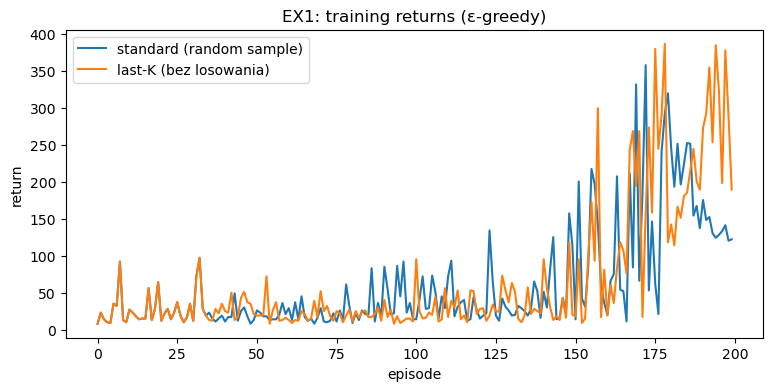

In [62]:
# Porównanie: standard DQN (losowe sample) vs "bez replay sampling" (ostatnie batch_size)

eps_start, eps_end, eps_decay_steps = 1.0, 0.05, 10_000
epsilon_fn = lambda step, ep: epsilon_by_step(step, eps_start, eps_end, eps_decay_steps)

sample_random = lambda buf, bs: buf.sample(bs)

# 1) baseline: standard
q_std, st_std = train_dqn_experiment(
    update_fn=dqn_update,
    sample_fn=sample_random,
    epsilon_fn=epsilon_fn,
    episodes=200,
    seed=0,
    use_target=True,
    verbose=False,
    eval_every=50,
)

# 2) ablation: bez losowania (ostatnie przejścia)
q_last, st_last = train_dqn_experiment(
    update_fn=dqn_update,
    sample_fn=sample_last,
    epsilon_fn=epsilon_fn,
    episodes=200,
    seed=0,
    use_target=True,
    verbose=False,
    eval_every=50,
)

m_std, s_std = evaluate_policy("CartPole-v1", lambda ob: greedy_action(q_std, ob), episodes=30, seed=123)
m_last, s_last = evaluate_policy("CartPole-v1", lambda ob: greedy_action(q_last, ob), episodes=30, seed=123)

print("=== EX1: wyniki greedy eval (30 ep) ===")
print(f"standard (random sample): {m_std:.1f} ± {s_std:.1f}")
print(f"last-K (bez losowania) : {m_last:.1f} ± {s_last:.1f}")

plt.figure(figsize=(9,4))
plt.plot(st_std["returns"], label="standard (random sample)")
plt.plot(st_last["returns"], label="last-K (bez losowania)")
plt.title("EX1: training returns (ε-greedy)")
plt.xlabel("episode")
plt.ylabel("return")
plt.legend()
plt.show()


### Interpretacja wyniku (ważne!)

W tym uruchomieniu wariant **last-K (bez losowania)** dał wyższy wynik greedy eval niż standardowy replay sampling.

To **nie oznacza**, że replay buffer jest zbędny.

Dlaczego tak mogło wyjść?

- CartPole jest relatywnie prosty i krótkie okno ostatnich przejść bywa „bardziej aktualne” (bardziej on-policy).
- Replay sampling miesza nowe i stare doświadczenia; przy krótkim treningu i dużym ε może to chwilowo spowalniać poprawę.
- Wynik silnie zależy od seeda, długości treningu i harmonogramu ε.

Co jest celem ćwiczenia?

Celem jest pokazanie, że **sposób próbkowania danych zmienia dynamikę uczenia**.
Dla poważniejszych zadań i dłuższych treningów losowanie z bufferu zwykle daje:
- większą stabilność,
- mniejszą korelację próbek,
- lepszą powtarzalność.



In [72]:
seeds = [0,1,2,3,4]
out = []

for sd in seeds:
    q_std, _ = train_dqn_experiment(..., seed=sd, sample_fn=sample_random, verbose=False, eval_every=0)
    q_last,_ = train_dqn_experiment(..., seed=sd, sample_fn=sample_last,   verbose=False, eval_every=0)
    m_std,_  = evaluate_policy("CartPole-v1", lambda ob: greedy_action(q_std, ob),  episodes=20, seed=123)
    m_last,_ = evaluate_policy("CartPole-v1", lambda ob: greedy_action(q_last, ob), episodes=20, seed=123)
    out.append((sd, m_std, m_last))

out


TypeError: train_dqn_experiment() missing 1 required positional argument: 'epsilon_fn'

## Ćwiczenie 2 — Ablacja: bez Target Network (dlaczego target „ucieka”)

**Cel:** zobaczyć, że jeśli target liczysz tą samą siecią, która się uczy, to cel optymalizacji zmienia się z każdym krokiem, co psuje stabilność.

**Zadanie:**
W kodzie targetu zamień `target_net` na `q_net`, czyli:
- w targetcie użyj `q_net(s2)` zamiast `target_net(s2)`.

**Co porównać:**
- stabilność lossu,
- greedy eval,
- ewentualne „wybuchy” wartości Q.

**Wskazówka:**
To ćwiczenie ma często gorsze wyniki — i o to chodzi (dydaktycznie).


In [63]:
def dqn_update_no_target(q_net, q_tgt, optimizer, batch, gamma: float = 0.99):
    """
    DQN update BEZ target network:
      y = r + gamma*(1-done)*max_a' Q_theta(s', a')
    czyli q_next liczysz z q_net, nie z q_tgt.
    """
    s, a, r, s2, done = batch

    s_t  = torch.tensor(s,  dtype=torch.float32, device=device)
    a_t  = torch.tensor(a,  dtype=torch.int64,   device=device).unsqueeze(1)
    r_t  = torch.tensor(r,  dtype=torch.float32, device=device)
    s2_t = torch.tensor(s2, dtype=torch.float32, device=device)
    d_t  = torch.tensor(done, dtype=torch.float32, device=device)

    q_sa = q_net(s_t).gather(1, a_t).squeeze(1)

    with torch.no_grad():
        # TODO: q_next = max_a' Q_theta(s',a')  (UWAGA: z q_net, nie q_tgt)
        # hint: q_next = q_net...
        raise NotImplementedError("TODO: policz q_next z q_net(s2_t)")
        # TODO: y = ...

    # TODO: loss Huber i krok optymalizacji jak w dqn_update
    raise NotImplementedError("TODO: dokończ update")


### Rozwiązanie:

In [64]:
def dqn_update_no_target(q_net, q_tgt, optimizer, batch, gamma: float = 0.99):
    s, a, r, s2, done = batch

    s_t  = torch.tensor(s,  dtype=torch.float32, device=device)
    a_t  = torch.tensor(a,  dtype=torch.int64,   device=device).unsqueeze(1)
    r_t  = torch.tensor(r,  dtype=torch.float32, device=device)
    s2_t = torch.tensor(s2, dtype=torch.float32, device=device)
    d_t  = torch.tensor(done, dtype=torch.float32, device=device)

    q_sa = q_net(s_t).gather(1, a_t).squeeze(1)

    with torch.no_grad():
        q_next = q_net(s2_t).max(dim=1).values
        y = r_t + gamma * (1.0 - d_t) * q_next

    loss = F.smooth_l1_loss(q_sa, y)

    optimizer.zero_grad()
    loss.backward()
    nn.utils.clip_grad_norm_(q_net.parameters(), 10.0)
    optimizer.step()

    return float(loss.item())


=== EX2: wyniki greedy eval (30 ep) ===
standard (z target): 217.6 ± 47.2
no target network  : 9.4 ± 0.7


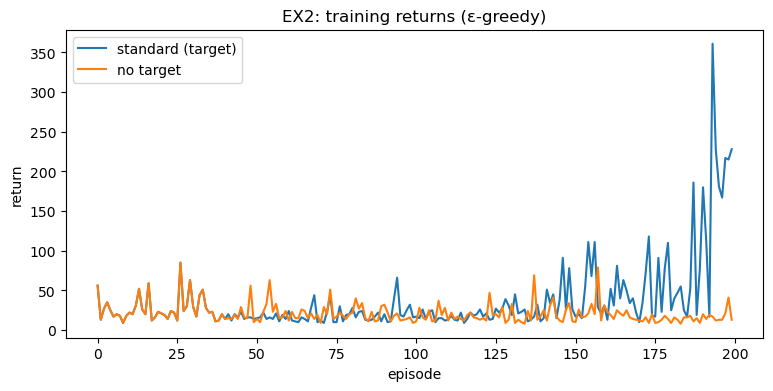

In [65]:
eps_start, eps_end, eps_decay_steps = 1.0, 0.05, 10_000
epsilon_fn = lambda step, ep: epsilon_by_step(step, eps_start, eps_end, eps_decay_steps)
sample_random = lambda buf, bs: buf.sample(bs)

# baseline: standard DQN
q_std, st_std = train_dqn_experiment(
    update_fn=dqn_update,
    sample_fn=sample_random,
    epsilon_fn=epsilon_fn,
    episodes=200,
    seed=1,
    use_target=True,
    verbose=False,
    eval_every=50,
)

# ablation: bez target network
q_nt, st_nt = train_dqn_experiment(
    update_fn=dqn_update_no_target,
    sample_fn=sample_random,
    epsilon_fn=epsilon_fn,
    episodes=200,
    seed=1,
    use_target=False,     # ważne: brak target net (q_tgt = q_net)
    verbose=False,
    eval_every=50,
)

m_std, s_std = evaluate_policy("CartPole-v1", lambda ob: greedy_action(q_std, ob), episodes=30, seed=123)
m_nt, s_nt   = evaluate_policy("CartPole-v1", lambda ob: greedy_action(q_nt, ob),  episodes=30, seed=123)

print("=== EX2: wyniki greedy eval (30 ep) ===")
print(f"standard (z target): {m_std:.1f} ± {s_std:.1f}")
print(f"no target network  : {m_nt:.1f} ± {s_nt:.1f}")

plt.figure(figsize=(9,4))
plt.plot(st_std["returns"], label="standard (target)")
plt.plot(st_nt["returns"], label="no target")
plt.title("EX2: training returns (ε-greedy)")
plt.xlabel("episode")
plt.ylabel("return")
plt.legend()
plt.show()


### Interpretacja wyniku

Wariant bez target network praktycznie się nie nauczył
(greedy eval ≈ losowa polityka).

Dlaczego?

Bez target network target ma postać:

y = r + γ max_a Q_θ(s', a)

czyli ta sama sieć, która się uczy, generuje też cel optymalizacji.

Efekt:
- po każdej aktualizacji zmienia się zarówno Q(s,a), jak i target,
- optymalizacja „goni ruchomy cel”,
- pojawiają się oscylacje i brak stabilnej konwergencji.

Target network działa jak:
- „zamrożona kopia”,
- stabilizator procesu uczenia,
- quasi-stacjonarny punkt odniesienia.

To ćwiczenie pokazuje, że target network nie jest drobnym detalem,
tylko kluczowym elementem stabilności DQN.


## Ćwiczenie 3 — ε-greedy: schedule po kroku vs po epizodzie

**Cel:** zrozumieć różnicę między:
- ε malejącym po *kroku* (global_step),
- ε malejącym po *epizodzie* (episode_idx).

**Zadanie:**
Zaimplementuj dwa warianty `epsilon`:
- `epsilon_by_step(step)` — jak w DQN,
- `epsilon_by_episode(ep)` — prostsze dydaktycznie.

**Co porównać:**
- jak szybko spada eksploracja,
- jak wygląda training return i greedy eval,
- jak zmienia się liczba kroków w epizodzie.

**Wskazówka:**
Przy schedule po kroku, spadek ε zależy od sumy przejść w bufferze.


In [ ]:
def epsilon_by_episode(ep: int, eps_start=1.0, eps_end=0.05, decay_episodes=400):
    """
    Liniowo: eps_start -> eps_end w ciągu decay_episodes epizodów.
    Po decay_episodes ma już zostać eps_end. 
    """
    # TODO: policz frac w [0,1], który mówi "jaki ułamek decay już minął"
    # hint: frac = min()
    # TODO: zwróć eps = end+(start-end)*(1-frac)
    raise NotImplementedError("TODO: epsilon_by_episode")


### Rozwiązanie:

In [66]:
def epsilon_by_episode(ep: int, eps_start=1.0, eps_end=0.05, decay_episodes=400):
    frac = min(1.0, ep / float(decay_episodes))
    return eps_end + (eps_start - eps_end) * (1.0 - frac)


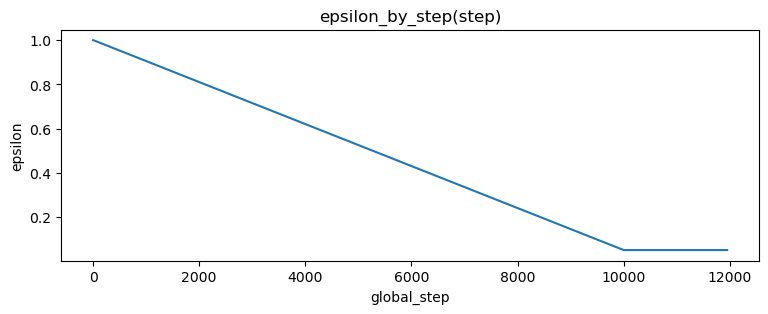

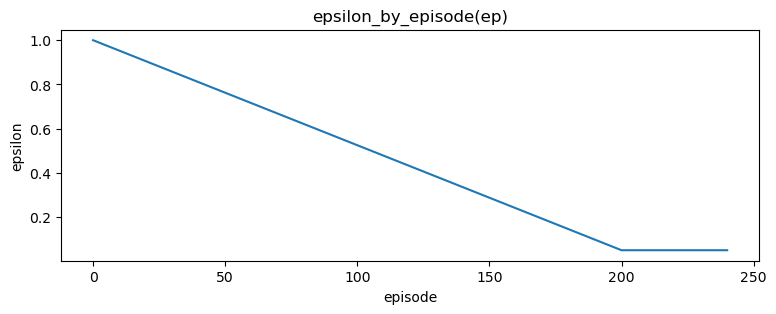

=== EX3: greedy eval (30 ep) ===
step-schedule   : 210.3 ± 56.9
episode-schedule: 195.0 ± 32.7


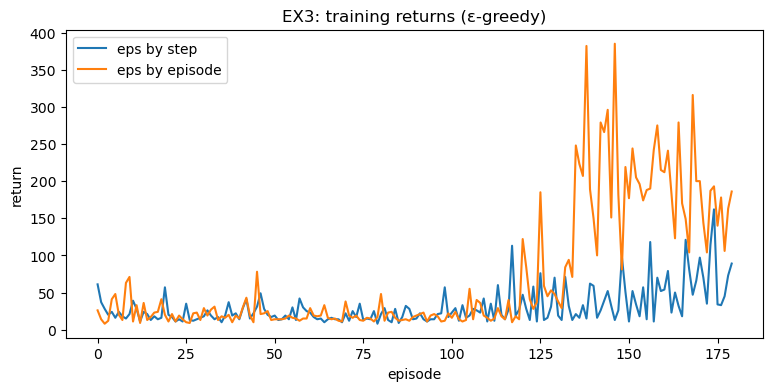

In [67]:
# 1) Szybki wykres samych schedule (intuicja)
eps_start, eps_end = 1.0, 0.05
decay_steps = 10_000
decay_episodes = 200

eps_step_curve = [epsilon_by_step(s, eps_start, eps_end, decay_steps) for s in range(0, 12_000, 50)]
eps_ep_curve   = [epsilon_by_episode(ep, eps_start, eps_end, decay_episodes) for ep in range(0, 241)]

plt.figure(figsize=(9,3))
plt.plot(range(0, 12_000, 50), eps_step_curve)
plt.title("epsilon_by_step(step)")
plt.xlabel("global_step")
plt.ylabel("epsilon")
plt.show()

plt.figure(figsize=(9,3))
plt.plot(range(0, 241), eps_ep_curve)
plt.title("epsilon_by_episode(ep)")
plt.xlabel("episode")
plt.ylabel("epsilon")
plt.show()

# 2) Porównanie treningu (krótkie): step-schedule vs episode-schedule
sample_random = lambda buf, bs: buf.sample(bs)

epsilon_fn_step = lambda step, ep: epsilon_by_step(step, eps_start, eps_end, decay_steps=10_000)
epsilon_fn_ep   = lambda step, ep: epsilon_by_episode(ep, eps_start, eps_end, decay_episodes=200)

q_step, st_step = train_dqn_experiment(
    update_fn=dqn_update,
    sample_fn=sample_random,
    epsilon_fn=epsilon_fn_step,
    episodes=180,
    seed=2,
    use_target=True,
    verbose=False,
    eval_every=60,
)

q_ep, st_ep = train_dqn_experiment(
    update_fn=dqn_update,
    sample_fn=sample_random,
    epsilon_fn=epsilon_fn_ep,
    episodes=180,
    seed=2,
    use_target=True,
    verbose=False,
    eval_every=60,
)

m_step, s_step = evaluate_policy("CartPole-v1", lambda ob: greedy_action(q_step, ob), episodes=30, seed=123)
m_ep, s_ep     = evaluate_policy("CartPole-v1", lambda ob: greedy_action(q_ep, ob),   episodes=30, seed=123)

print("=== EX3: greedy eval (30 ep) ===")
print(f"step-schedule   : {m_step:.1f} ± {s_step:.1f}")
print(f"episode-schedule: {m_ep:.1f} ± {s_ep:.1f}")

plt.figure(figsize=(9,4))
plt.plot(st_step["returns"], label="eps by step")
plt.plot(st_ep["returns"], label="eps by episode")
plt.title("EX3: training returns (ε-greedy)")
plt.xlabel("episode")
plt.ylabel("return")
plt.legend()
plt.show()


### Interpretacja wyniku

Oba harmonogramy ε działają, ale mają inną dynamikę.

ε malejące po epizodzie:
- szybciej ogranicza eksplorację,
- szybciej zwiększa exploitation,
- może dawać szybszy wzrost return,
- ale ma większą wariancję i mniej kontroli nad liczbą rzeczywistych kroków eksploracji.

ε malejące po kroku:
- zależy od liczby interakcji z środowiskiem,
- jest bardziej stabilne,
- jest standardem w implementacjach DQN.

W praktyce (szczególnie przy niestabilnych zadaniach)
schedule po kroku jest bardziej przewidywalny i bezpieczny.


## Ćwiczenie 4 — Double DQN (redukcja overestimation)

**Cel:** zobaczyć, że w vanilla DQN operator `max` ma tendencję do zawyżania wartości (overestimation).

### Vanilla DQN target:
$y = r + \gamma(1-d)\max_{a'}Q_{\theta^-}(s',a')$

### Double DQN target:
1) wybór akcji robi sieć ucząca się:
$a^* = \arg\max_{a'} Q_\theta(s',a')$

2) ocena wartości robi target network:
$y = r + \gamma(1-d) Q_{\theta^-}(s', a^*)$

**Zadanie:**
Zaimplementuj Double DQN w miejscu liczenia targetu `y`.

**Co porównać:**
- stabilność greedy eval,
- średnią wartości `max Q(s,·)` w trakcie treningu (często mniejsza w Double DQN).


In [ ]:
def dqn_update_double(q_net, q_tgt, optimizer, batch, gamma: float = 0.99):
    """
    Double DQN:
      a* = argmax_a Q_theta(s',a)
      y  = r + gamma*(1-done) * Q_target(s', a*)
    """
    s, a, r, s2, done = batch

    s_t  = torch.tensor(s,  dtype=torch.float32, device=device)
    a_t  = torch.tensor(a,  dtype=torch.int64,   device=device).unsqueeze(1)
    r_t  = torch.tensor(r,  dtype=torch.float32, device=device)
    s2_t = torch.tensor(s2, dtype=torch.float32, device=device)
    d_t  = torch.tensor(done, dtype=torch.float32, device=device)

    q_sa = q_net(s_t).gather(1, a_t).squeeze(1)

    with torch.no_grad():
        # TODO 1: a_star = argmax_a Q_theta(s',a)  (z q_net)
        # hint: a_star = q_net(s2_t)...        # (B,)
        # TODO 2: q_next = Q_target(s', a_star)          (z q_tgt)
        # hint: q_next = q_tgt(s2_t)....
        # TODO 3: y = r_t + gamma*(1-d_t)*q_next
        raise NotImplementedError("TODO: Double DQN target")

    # TODO: loss Huber i krok optymalizacji
    raise NotImplementedError("TODO: dokończ update")


### Rozwiązanie:

In [68]:
def dqn_update_double(q_net, q_tgt, optimizer, batch, gamma: float = 0.99):
    s, a, r, s2, done = batch

    s_t  = torch.tensor(s,  dtype=torch.float32, device=device)
    a_t  = torch.tensor(a,  dtype=torch.int64,   device=device).unsqueeze(1)
    r_t  = torch.tensor(r,  dtype=torch.float32, device=device)
    s2_t = torch.tensor(s2, dtype=torch.float32, device=device)
    d_t  = torch.tensor(done, dtype=torch.float32, device=device)

    q_sa = q_net(s_t).gather(1, a_t).squeeze(1)

    with torch.no_grad():
        a_star = q_net(s2_t).argmax(dim=1)  # (B,)
        q_next = q_tgt(s2_t).gather(1, a_star.unsqueeze(1)).squeeze(1)  # (B,)
        y = r_t + gamma * (1.0 - d_t) * q_next

    loss = F.smooth_l1_loss(q_sa, y)

    optimizer.zero_grad()
    loss.backward()
    nn.utils.clip_grad_norm_(q_net.parameters(), 10.0)
    optimizer.step()

    return float(loss.item())


=== EX4: greedy eval (30 ep) ===
standard DQN : 105.4 ± 6.1
Double DQN   : 111.0 ± 9.1


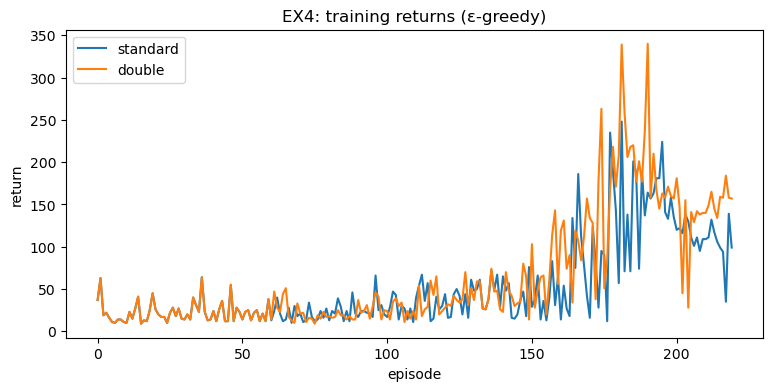

In [69]:
eps_start, eps_end, eps_decay_steps = 1.0, 0.05, 10_000
epsilon_fn = lambda step, ep: epsilon_by_step(step, eps_start, eps_end, eps_decay_steps)
sample_random = lambda buf, bs: buf.sample(bs)

# baseline: standard
q_std, st_std = train_dqn_experiment(
    update_fn=dqn_update,
    sample_fn=sample_random,
    epsilon_fn=epsilon_fn,
    episodes=220,
    seed=3,
    use_target=True,
    verbose=False,
    eval_every=55,
)

# double dqn
q_dd, st_dd = train_dqn_experiment(
    update_fn=dqn_update_double,
    sample_fn=sample_random,
    epsilon_fn=epsilon_fn,
    episodes=220,
    seed=3,
    use_target=True,
    verbose=False,
    eval_every=55,
)

m_std, s_std = evaluate_policy("CartPole-v1", lambda ob: greedy_action(q_std, ob), episodes=30, seed=123)
m_dd, s_dd   = evaluate_policy("CartPole-v1", lambda ob: greedy_action(q_dd, ob),  episodes=30, seed=123)

print("=== EX4: greedy eval (30 ep) ===")
print(f"standard DQN : {m_std:.1f} ± {s_std:.1f}")
print(f"Double DQN   : {m_dd:.1f} ± {s_dd:.1f}")

plt.figure(figsize=(9,4))
plt.plot(st_std["returns"], label="standard")
plt.plot(st_dd["returns"], label="double")
plt.title("EX4: training returns (ε-greedy)")
plt.xlabel("episode")
plt.ylabel("return")
plt.legend()
plt.show()


## Dodatek

In [73]:
@torch.no_grad()
def estimate_maxQ(q_net, n_states=512, seed=0):
    env = make_env("CartPole-v1", seed=seed, render=False)
    obs_list = []
    obs = reset_env(env, seed=seed)
    done = False
    for _ in range(n_states):
        # losowa akcja tylko po to, żeby zebrać przekrój stanów
        a = env.action_space.sample()
        obs2, r, done = step_env(env, a)
        obs_list.append(obs)
        obs = obs2
        if done:
            obs = reset_env(env, seed=seed+1)
    env.close()

    X = torch.tensor(np.array(obs_list), dtype=torch.float32, device=device)
    q = q_net(X)
    maxq = q.max(dim=1).values
    return float(maxq.mean().item()), float(maxq.std().item()), float(maxq.max().item())


In [74]:
m_std, s_std, mx_std = estimate_maxQ(q_std, seed=0)
m_dd,  s_dd,  mx_dd  = estimate_maxQ(q_dd,  seed=0)

print("=== Q-value inflation check ===")
print(f"standard: mean±std={m_std:.3f}±{s_std:.3f}, max={mx_std:.3f}")
print(f"double  : mean±std={m_dd:.3f}±{s_dd:.3f}, max={mx_dd:.3f}")


=== Q-value inflation check ===
standard: mean±std=19.212±2.871, max=20.720
double  : mean±std=23.368±4.134, max=25.623


### Interpretacja wyniku (Ćwiczenie 4)

Double DQN nie zawsze daje dużo wyższy return (szczególnie w CartPole).
Główna różnica to redukcja *overestimation bias* wynikającego z operatora `max`.

Dlatego sensownie jest porównywać nie tylko return, ale też diagnostykę wartości Q,
np. średnie i maksymalne `max_a Q(s,a)` na losowej próbce stanów.

W trudniejszych zadaniach (np. Atari) Double DQN daje zwykle wyraźniejszą poprawę stabilności.


## Ćwiczenie 5 (bonus) — n-step return (np. 3-step)

**Cel:** zrozumieć, że 1-step TD to tylko jeden przypadek.
n-step jest mostem do advantage/GAE w A2C/PPO.

Dla 3-step target (uproszczony):
$y = r_t + \gamma r_{t+1} + \gamma^2 r_{t+2} + \gamma^3(1-d)\max Q_{\theta^-}(s_{t+3},\cdot)$

**Zadanie:**
Zbierz w rolloutcie 3 kroki (lub dopóki `done`) i policz target 3-step.

**Wskazówka:**
Najprościej: w pętli epizodu trzymaj małą kolejkę ostatnich przejść i aktualizuj, gdy masz 3 nagrody.


In [ ]:
class ReplayBufferNStep:
    def __init__(self, capacity: int):
        self.buffer = deque(maxlen=capacity)

    def push(self, s, a, Rn, sN, doneN, gammaN):
        self.buffer.append((np.array(s, dtype=np.float32),
                            int(a),
                            float(Rn),
                            np.array(sN, dtype=np.float32),
                            bool(doneN),
                            float(gammaN)))

    def sample(self, batch_size: int):
        batch = random.sample(self.buffer, batch_size)
        s, a, Rn, sN, doneN, gammaN = map(np.array, zip(*batch))
        return (s,
                a,
                Rn.astype(np.float32),
                sN,
                doneN.astype(np.float32),
                gammaN.astype(np.float32))

    def __len__(self):
        return len(self.buffer)


class NStepAdder:
    """
    Zbiera kroki i wypuszcza przejście n-step:
      (s0, a0, Rn, sN, doneN, gammaN)

    gdzie:
      Rn = r0 + gamma*r1 + ... + gamma^(k-1)*r_{k-1}
      gammaN = gamma^k
      k = n (albo mniej jeśli epizod się skończył wcześniej)
    """
    def __init__(self, n=3, gamma=0.99):
        self.n = int(n)
        self.gamma = float(gamma)
        self.q = deque()  # elementy: (s,a,r,s2,done)

    def reset(self):
        self.q.clear()

    def add(self, s, a, r, s2, done):
        self.q.append((s, a, r, s2, done))

        if len(self.q) < self.n:
            return None

        # TODO 1: policz R oraz k (ile kroków faktycznie agregujesz)
        # hint:
        #   R = 0.0
        #   k = 0
        #   for i, (_,_,ri,_,di) in enumerate(self.q):
        #       R += gamma**i * ri
        #       k = i+1
        #       breka if di

        # TODO 2: zdefiniuj:
        #   s0,a0 = q[0][] - 0 and 1 
        #   sN, doneN = stan/koniec po k krokach (czyli s2 i done z kroku k-1)
        #   gammaN = self.gamma**k

        # TODO 3: usuń najstarszy element (przesuwamy okno)
        # hint: self.q. (pop from left)

        raise NotImplementedError("TODO: NStepAdder.add")

    def flush_end_of_episode(self):
        """
        Wypuść resztę przejść krótszych niż n (na końcu epizodu).
        """
        out = []
        while len(self.q) > 0:
            # TODO: policz R, k, s0,a0, sN, doneN, gammaN analogicznie jak w add()
            # potem usuń najstarszy element i dodaj transition do out
            raise NotImplementedError("TODO: NStepAdder.flush_end_of_episode")
        return out


def dqn_update_nstep(q_net, q_tgt, optimizer, batch, gamma: float = 0.99):
    """
    batch: (s, a, Rn, sN, doneN, gammaN)
    target:
      y = Rn + (1-doneN) * gammaN * max_a Q_target(sN, a)
    """
    s, a, Rn, sN, doneN, gammaN = batch

    s_t  = torch.tensor(s,  dtype=torch.float32, device=device)
    a_t  = torch.tensor(a,  dtype=torch.int64,   device=device).unsqueeze(1)
    R_t  = torch.tensor(Rn, dtype=torch.float32, device=device)
    sN_t = torch.tensor(sN, dtype=torch.float32, device=device)
    d_t  = torch.tensor(doneN, dtype=torch.float32, device=device)
    gN_t = torch.tensor(gammaN, dtype=torch.float32, device=device)

    q_sa = q_net(s_t).gather(1, a_t).squeeze(1)

    with torch.no_grad():
        q_next = q_tgt(sN_t).max(dim=1).values
        # TODO: y = R_t + (1-d_t) * gN_t * q_next
        raise NotImplementedError("TODO: policz target y")

    # TODO: loss Huber i krok optymalizacji
    raise NotImplementedError("TODO: dokończ update")


def train_dqn_nstep(
    *,
    n=3,
    seed=0,
    episodes=220,
    gamma=0.99,
    lr=3e-4,
    hidden=128,
    buffer_capacity=50_000,
    batch_size=64,
    start_learning=800,
    train_freq=1,
    target_update=500,
    eps_start=1.0,
    eps_end=0.05,
    eps_decay_steps=10_000,
    max_steps=500,
    eval_every=55,
    eval_episodes=10,
    verbose=False,
):
    seed_everything(seed)
    env = make_env("CartPole-v1", seed=seed, render=False)
    obs_dim = env.observation_space.shape[0]
    act_dim = env.action_space.n

    q_net = QNet(obs_dim, act_dim, hidden=hidden).to(device)
    q_tgt = QNet(obs_dim, act_dim, hidden=hidden).to(device)
    q_tgt.load_state_dict(q_net.state_dict())
    q_tgt.eval()

    optimizer = optim.Adam(q_net.parameters(), lr=lr)
    buffer = ReplayBufferNStep(buffer_capacity)
    nstep = NStepAdder(n=n, gamma=gamma)

    returns = []
    eps_hist = []
    eval_points = []
    global_step = 0

    for ep in range(episodes):
        obs = reset_env(env, seed=seed + ep)
        nstep.reset()
        ep_return = 0.0
        ep_losses = []

        for t in range(max_steps):
            eps = epsilon_by_step(global_step, eps_start, eps_end, eps_decay_steps)
            a = select_action(q_net, obs, eps, act_dim)

            obs2, r, done = step_env(env, a)
            ep_return += r

            out = nstep.add(obs, a, r, obs2, done)
            if out is not None:
                s0, a0, Rn, sN, doneN, gammaN = out
                buffer.push(s0, a0, Rn, sN, doneN, gammaN)

            if len(buffer) >= start_learning and (global_step % train_freq == 0):
                batch = buffer.sample(batch_size)
                loss = dqn_update_nstep(q_net, q_tgt, optimizer, batch, gamma=gamma)
                ep_losses.append(loss)

            if global_step % target_update == 0:
                q_tgt.load_state_dict(q_net.state_dict())

            obs = obs2
            global_step += 1

            if done:
                break

        # flush resztek na końcu epizodu
        for tr in nstep.flush_end_of_episode():
            s0, a0, Rn, sN, doneN, gammaN = tr
            buffer.push(s0, a0, Rn, sN, doneN, gammaN)

        returns.append(ep_return)
        eps_hist.append(eps)

        if eval_every and ((ep + 1) % eval_every == 0):
            mean_eval, std_eval = evaluate_policy(
                "CartPole-v1",
                policy_fn=lambda ob: greedy_action(q_net, ob),
                episodes=eval_episodes,
                seed=seed + 10_000 + ep,
            )
            eval_points.append((ep + 1, mean_eval))
            if verbose:
                print(f"   [eval] ep {ep+1:4d} | greedy mean±std = {mean_eval:6.1f} ± {std_eval:4.1f}")

    env.close()
    stats = {"returns": returns, "epsilon": eps_hist, "eval_points": eval_points, "steps": global_step}
    return q_net, stats


### Rozwiązanie:

In [70]:
class NStepAdder:
    def __init__(self, n=3, gamma=0.99):
        self.n = int(n)
        self.gamma = float(gamma)
        self.q = deque()

    def reset(self):
        self.q.clear()

    def _compute_R_k_sN_done(self):
        R = 0.0
        k = 0
        sN = None
        doneN = False
        for i, (_, _, ri, s2i, di) in enumerate(self.q):
            R += (self.gamma ** i) * float(ri)
            k = i + 1
            sN = s2i
            doneN = bool(di)
            if di:
                break
        gammaN = self.gamma ** k
        return R, k, sN, doneN, gammaN

    def add(self, s, a, r, s2, done):
        self.q.append((s, a, r, s2, done))
        if len(self.q) < self.n:
            return None

        R, k, sN, doneN, gammaN = self._compute_R_k_sN_done()
        s0, a0 = self.q[0][0], self.q[0][1]

        self.q.popleft()
        return (s0, a0, R, sN, doneN, gammaN)

    def flush_end_of_episode(self):
        out = []
        while len(self.q) > 0:
            R, k, sN, doneN, gammaN = self._compute_R_k_sN_done()
            s0, a0 = self.q[0][0], self.q[0][1]
            out.append((s0, a0, R, sN, doneN, gammaN))
            self.q.popleft()
        return out


def dqn_update_nstep(q_net, q_tgt, optimizer, batch, gamma: float = 0.99):
    s, a, Rn, sN, doneN, gammaN = batch

    s_t  = torch.tensor(s,  dtype=torch.float32, device=device)
    a_t  = torch.tensor(a,  dtype=torch.int64,   device=device).unsqueeze(1)
    R_t  = torch.tensor(Rn, dtype=torch.float32, device=device)
    sN_t = torch.tensor(sN, dtype=torch.float32, device=device)
    d_t  = torch.tensor(doneN, dtype=torch.float32, device=device)
    gN_t = torch.tensor(gammaN, dtype=torch.float32, device=device)

    q_sa = q_net(s_t).gather(1, a_t).squeeze(1)

    with torch.no_grad():
        q_next = q_tgt(sN_t).max(dim=1).values
        y = R_t + (1.0 - d_t) * gN_t * q_next

    loss = F.smooth_l1_loss(q_sa, y)

    optimizer.zero_grad()
    loss.backward()
    nn.utils.clip_grad_norm_(q_net.parameters(), 10.0)
    optimizer.step()

    return float(loss.item())


=== EX5: greedy eval (30 ep) ===
1-step: 189.7 ± 33.3
3-step: 500.0 ± 0.0


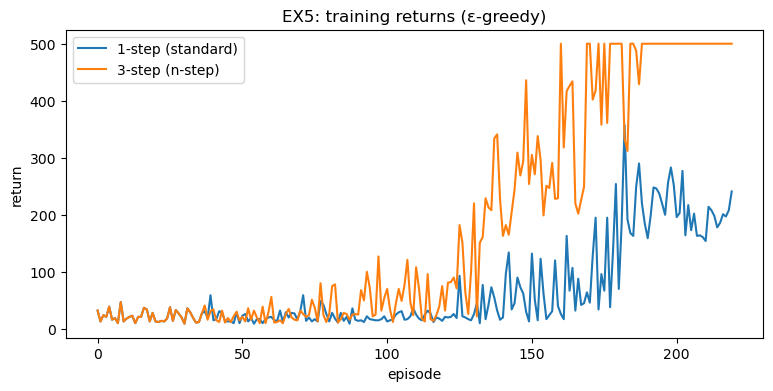

In [71]:
# Porównanie 1-step (standard) vs 3-step (n-step)

# 1-step baseline (standard DQN)
eps_start, eps_end, eps_decay_steps = 1.0, 0.05, 10_000
epsilon_fn = lambda step, ep: epsilon_by_step(step, eps_start, eps_end, eps_decay_steps)
sample_random = lambda buf, bs: buf.sample(bs)

q_1, st_1 = train_dqn_experiment(
    update_fn=dqn_update,
    sample_fn=sample_random,
    epsilon_fn=epsilon_fn,
    episodes=220,
    seed=4,
    use_target=True,
    verbose=False,
    eval_every=55,
)

# 3-step
q_3, st_3 = train_dqn_nstep(
    n=3,
    seed=4,
    episodes=220,
    start_learning=800,
    verbose=False,
)

m_1, s_1 = evaluate_policy("CartPole-v1", lambda ob: greedy_action(q_1, ob), episodes=30, seed=123)
m_3, s_3 = evaluate_policy("CartPole-v1", lambda ob: greedy_action(q_3, ob), episodes=30, seed=123)

print("=== EX5: greedy eval (30 ep) ===")
print(f"1-step: {m_1:.1f} ± {s_1:.1f}")
print(f"3-step: {m_3:.1f} ± {s_3:.1f}")

plt.figure(figsize=(9,4))
plt.plot(st_1["returns"], label="1-step (standard)")
plt.plot(st_3["returns"], label="3-step (n-step)")
plt.title("EX5: training returns (ε-greedy)")
plt.xlabel("episode")
plt.ylabel("return")
plt.legend()
plt.show()


### Interpretacja wyniku (Ćwiczenie 5 — n-step)

Wariant 3-step może uczyć się dużo szybciej niż 1-step TD, bo w jednej aktualizacji
przenosi informację o nagrodach kilka kroków wstecz.

1-step TD propaguje „credit” o 1 krok na update:

$
y = r_t + γ max Q(s_{t+1},·)
$

3-step robi to szybciej:

$
y = r_t + γ r_{t+1} + γ^2 r_{t+2} + γ^3 max Q(s_{t+3},·)
$

W CartPole (gęsta nagroda + prosta dynamika) taki n-step często daje duży skok jakości
i może szybko doprowadzić do wyniku 500/500 w greedy ewaluacji.

To ćwiczenie jest też mostem do A2C/PPO:
rollouty wielokrokowe i GAE to w praktyce uogólnienie n-step TD.
